## Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 20,10
#from keras.optimizers import Adam , Adamax, Adadelta, Adagrad, RMSprop, Nadam, SGD
from keras.models import load_model
from tensorflow.keras.optimizers import Adam , Adamax, Adadelta, Adagrad, RMSprop, Nadam, SGD


from keras.models import Sequential
from keras.layers import Dense, RepeatVector,LSTM, Embedding, Conv2D, MaxPooling2D, Flatten, Dropout, GRU
from keras.layers import TimeDistributed
from keras.layers import Conv1D, MaxPooling1D

import math
from tensorflow.keras.layers import Lambda
from tensorflow.keras import backend as K
from scipy import stats
import statistics as sts
from scipy.stats.mstats import gmean

plt.style.use('fivethirtyeight')

from sklearn.metrics import mean_squared_error

#from google.colab import drive
#drive.mount('/content/drive')
plt.style.use('fivethirtyeight')

## Data

### XAUUSD

In [3]:
df_15m = pd.read_csv(r'C:\Users\Hamkaran\Desktop\Final_Project\extracted\XAUUSD_M15_201703100100_202106291215.csv', sep = "\t")[6292:101080]
print(len(df_15m))

94788


In [4]:
df_15m

,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<TICKVOL>,<VOL>,<SPREAD>
6292,2017.06.16,01:00:00,1254.32,1254.37,1253.98,1254.17,166,93340,35
6293,2017.06.16,01:15:00,1254.16,1254.28,1253.84,1254.09,205,125989,34
6294,2017.06.16,01:30:00,1254.09,1254.93,1253.97,1254.88,187,96945,26
6295,2017.06.16,01:45:00,1254.88,1254.98,1254.33,1254.60,218,112905,27
6296,2017.06.16,02:00:00,1254.58,1254.94,1254.39,1254.58,404,238260,30
...,...,...,...,...,...,...,...,...,...
101075,2021.06.29,04:30:00,1776.68,1777.75,1775.44,1775.50,647,0,4
101076,2021.06.29,04:45:00,1775.50,1776.48,1774.45,1774.54,408,0,4
101077,2021.06.29,05:00:00,1774.50,1775.10,1774.08,1774.54,623,0,4
101078,2021.06.29,05:15:00,1774.54,1775.39,1774.46,1775.36,305,0,10


In [5]:
df_15m.head

<bound method NDFrame.head of             <DATE>    <TIME>   <OPEN>   <HIGH>    <LOW>  <CLOSE>  <TICKVOL>  \
6292    2017.06.16  01:00:00  1254.32  1254.37  1253.98  1254.17        166   
6293    2017.06.16  01:15:00  1254.16  1254.28  1253.84  1254.09        205   
6294    2017.06.16  01:30:00  1254.09  1254.93  1253.97  1254.88        187   
6295    2017.06.16  01:45:00  1254.88  1254.98  1254.33  1254.60        218   
6296    2017.06.16  02:00:00  1254.58  1254.94  1254.39  1254.58        404   
...            ...       ...      ...      ...      ...      ...        ...   
101075  2021.06.29  04:30:00  1776.68  1777.75  1775.44  1775.50        647   
101076  2021.06.29  04:45:00  1775.50  1776.48  1774.45  1774.54        408   
101077  2021.06.29  05:00:00  1774.50  1775.10  1774.08  1774.54        623   
101078  2021.06.29  05:15:00  1774.54  1775.39  1774.46  1775.36        305   
101079  2021.06.29  05:30:00  1775.36  1775.90  1775.02  1775.53        404   

         <VOL>  <SPRE

In [6]:
df_15m.tail

<bound method NDFrame.tail of             <DATE>    <TIME>   <OPEN>   <HIGH>    <LOW>  <CLOSE>  <TICKVOL>  \
6292    2017.06.16  01:00:00  1254.32  1254.37  1253.98  1254.17        166   
6293    2017.06.16  01:15:00  1254.16  1254.28  1253.84  1254.09        205   
6294    2017.06.16  01:30:00  1254.09  1254.93  1253.97  1254.88        187   
6295    2017.06.16  01:45:00  1254.88  1254.98  1254.33  1254.60        218   
6296    2017.06.16  02:00:00  1254.58  1254.94  1254.39  1254.58        404   
...            ...       ...      ...      ...      ...      ...        ...   
101075  2021.06.29  04:30:00  1776.68  1777.75  1775.44  1775.50        647   
101076  2021.06.29  04:45:00  1775.50  1776.48  1774.45  1774.54        408   
101077  2021.06.29  05:00:00  1774.50  1775.10  1774.08  1774.54        623   
101078  2021.06.29  05:15:00  1774.54  1775.39  1774.46  1775.36        305   
101079  2021.06.29  05:30:00  1775.36  1775.90  1775.02  1775.53        404   

         <VOL>  <SPRE

## Data Changes

In [7]:
df_15m['<DATE>'] = df_15m['<DATE>'] + '  ' + df_15m['<TIME>']
df_15m = df_15m.drop(columns=['<TIME>', '<VOL>','<SPREAD>', '<TICKVOL>'])
df_15m = df_15m.set_index('<DATE>')


In [8]:
df_15m

,<OPEN>,<HIGH>,<LOW>,<CLOSE>
<DATE>,,,,
2017.06.16 01:00:00,1254.32,1254.37,1253.98,1254.17
2017.06.16 01:15:00,1254.16,1254.28,1253.84,1254.09
2017.06.16 01:30:00,1254.09,1254.93,1253.97,1254.88
2017.06.16 01:45:00,1254.88,1254.98,1254.33,1254.60
2017.06.16 02:00:00,1254.58,1254.94,1254.39,1254.58
...,...,...,...,...
2021.06.29 04:30:00,1776.68,1777.75,1775.44,1775.50
2021.06.29 04:45:00,1775.50,1776.48,1774.45,1774.54
2021.06.29 05:00:00,1774.50,1775.10,1774.08,1774.54


In [9]:
#data_daily = data_daily.iloc[:, 1:2].values
df_15m = np.array(df_15m)
df_15m

array([[1254.32, 1254.37, 1253.98, 1254.17],
       [1254.16, 1254.28, 1253.84, 1254.09],
       [1254.09, 1254.93, 1253.97, 1254.88],
       ...,
       [1774.5 , 1775.1 , 1774.08, 1774.54],
       [1774.54, 1775.39, 1774.46, 1775.36],
       [1775.36, 1775.9 , 1775.02, 1775.53]])

## Train and Test

In [10]:
len(df_15m)

94788

In [11]:
training_size15m = int(len(df_15m)*0.6)
training_size15m

56872

In [12]:
test_size15m = len(df_15m) - training_size15m
test_size15m

37916

In [13]:
train_data15m = df_15m[0:training_size15m]
train_data15m

array([[1254.32, 1254.37, 1253.98, 1254.17],
       [1254.16, 1254.28, 1253.84, 1254.09],
       [1254.09, 1254.93, 1253.97, 1254.88],
       ...,
       [1468.74, 1468.81, 1467.73, 1468.13],
       [1468.13, 1468.77, 1467.63, 1467.73],
       [1467.71, 1468.08, 1467.6 , 1467.74]])

In [14]:
df_15m[56872:56873]

array([[1467.73, 1468.15, 1467.62, 1467.83]])

In [15]:
test_data15m = df_15m[training_size15m:len(df_15m)]
test_data15m

array([[1467.73, 1468.15, 1467.62, 1467.83],
       [1467.83, 1468.27, 1467.67, 1467.81],
       [1467.82, 1467.94, 1466.94, 1467.13],
       ...,
       [1774.5 , 1775.1 , 1774.08, 1774.54],
       [1774.54, 1775.39, 1774.46, 1775.36],
       [1775.36, 1775.9 , 1775.02, 1775.53]])

In [16]:
training_size15m = int(len(df_15m)*0.6)
test_size15m = len(df_15m) - training_size15m
train_data15m = df_15m[0:training_size15m]
test_data15m = df_15m[training_size15m:len(df_15m)]

In [17]:
print(train_data15m.shape, test_data15m.shape)

(56872, 4) (37916, 4)


In [18]:
## Validation Data
valid_h_maxxmin15m = train_data15m[50000:,:]
print('valid x shape:',valid_h_maxxmin15m.shape)

valid x shape: (6872, 4)


In [19]:
train_data15m = train_data15m[:50000,:]
train_data15m.shape

(50000, 4)

## max, min, mean, std, harmonic

In [20]:
meann_data15m = (train_data15m[:,0] + train_data15m[:,1] + train_data15m[:,2] + train_data15m[:,3])/4
meann_data15m

array([1254.21  , 1254.0925, 1254.4675, ..., 1440.4   , 1438.7625,
       1438.65  ])

In [21]:
meann_data15m.shape

(50000,)

In [22]:
mm = np.max(train_data15m[:,1])
mm

1452.92

In [23]:
maxx_15m = np.max(meann_data15m)
minn_15m = np.min(meann_data15m)
print('max =', maxx_15m, '\nmin =', minn_15m)

max = 1448.69 
min = 1163.3600000000001


In [24]:
mean15m = np.mean(meann_data15m)
print('mean =', mean15m)

mean = 1285.4725827500001


In [25]:
harmonic_mean15m = sts.harmonic_mean(meann_data15m)
print('harmonic_mean =', harmonic_mean15m)

harmonic_mean = 1283.3281290653294


In [26]:
stdev15m = sts.stdev(meann_data15m)
print('stdev =', stdev15m)

stdev = 52.78806954758346


## Normalizations

In [27]:
train_h_maxxmin15m = (train_data15m - harmonic_mean15m) / (maxx_15m - minn_15m)
test_h_maxxmin15m = (test_data15m - harmonic_mean15m) / (maxx_15m - minn_15m)

In [28]:
valid_hmaxxmin15m = (valid_h_maxxmin15m - harmonic_mean15m) / (maxx_15m - minn_15m)

In [29]:
valid_hmaxxmin15m.shape

(6872, 4)

In [30]:
train_h_maxxmin15m

array([[-0.10166519, -0.10148996, -0.10285679, -0.1021909 ],
       [-0.10222595, -0.10180538, -0.10334745, -0.10247128],
       [-0.10247128, -0.09952732, -0.10289184, -0.09970255],
       ...,
       [ 0.55518828,  0.55806214,  0.54358767,  0.54512975],
       [ 0.54555031,  0.55087748,  0.53938202,  0.54320216],
       [ 0.5432372 ,  0.54709239,  0.5407839 ,  0.54632135]])

In [30]:
test_h_maxxmin15m

array([[0.64627579, 0.64774777, 0.64589027, 0.64662626],
       [0.64662626, 0.64816833, 0.64606551, 0.64655617],
       [0.64659121, 0.64701178, 0.64350707, 0.64417296],
       ...,
       [1.72141685, 1.72351968, 1.71994487, 1.72155704],
       [1.72155704, 1.72453605, 1.72127667, 1.72443091],
       [1.72443091, 1.72632345, 1.72323931, 1.72502671]])

## Find x_y Train and Test

In [31]:
def create_dataset(dataset, time_step):
    dataX, dataY = [], []
    for i in range(len(dataset)-time_step):
        a = dataset[i:(i+time_step),:]
        dataX.append(a)
        dataY.append(dataset[i+time_step,:])
    return np.array(dataX), np.array(dataY)

In [32]:
time_step = 4
#4 , 12 , 60

In [33]:
X_train_h_maxxmin15m, Y_train_h_maxxmin15m = create_dataset(train_h_maxxmin15m, time_step)
X_test_h_maxxmin15m, Y_test_h_maxxmin15m = create_dataset(test_h_maxxmin15m, time_step)
X_valid_h_maxxmin15m, Y_valid_h_maxxmin15m = create_dataset(valid_hmaxxmin15m, time_step)


In [34]:
print('train x shape:',X_train_h_maxxmin15m.shape, 'train y shape:',Y_train_h_maxxmin15m.shape)
print('test x shape:',X_test_h_maxxmin15m.shape, 'test y shape:',Y_test_h_maxxmin15m.shape)
print('valid x shape:',X_valid_h_maxxmin15m.shape, 'valid y shape:',Y_valid_h_maxxmin15m.shape)

train x shape: (49996, 4, 4) train y shape: (49996, 4)
test x shape: (37912, 4, 4) test y shape: (37912, 4)
valid x shape: (6868, 4, 4) valid y shape: (6868, 4)


In [35]:
X_train_h_maxxmin15m[1,:]

array([[-0.10222595, -0.10180538, -0.10334745, -0.10247128],
       [-0.10247128, -0.09952732, -0.10289184, -0.09970255],
       [-0.09970255, -0.09935208, -0.10163014, -0.10068387],
       [-0.10075397, -0.09949227, -0.10141986, -0.10075397]])

In [36]:
Y_train_h_maxxmin15m

array([[-0.10075397, -0.09949227, -0.10141986, -0.10075397],
       [-0.10075397, -0.09924694, -0.10148996, -0.09949227],
       [-0.09949227, -0.09931703, -0.10127967, -0.10078901],
       ...,
       [ 0.55518828,  0.55806214,  0.54358767,  0.54512975],
       [ 0.54555031,  0.55087748,  0.53938202,  0.54320216],
       [ 0.5432372 ,  0.54709239,  0.5407839 ,  0.54632135]])

## Model

In [37]:
unit = 128
#256
dense = 4
epoch = 50
bach = 7
#32, 16
tanh = 'tanh'
relu = 'relu'
kernel = 2
#3
lr1 = 0.0001
#0.001, 0.00001

### 15min model

In [38]:
print('--------------------------------------------------------------------------------------')
print('Normal XAUUSD 15min (train_data15m - harmonic_mean15m) / (maxx_15m - minn_15m)')
print('--------------------------------------------------------------------------------------')
print('CNN is started')

modelCNN_h_maxxmin15m = Sequential()
modelCNN_h_maxxmin15m.add(Conv1D(filters = unit, activation = tanh, kernel_size = kernel, input_shape = (X_train_h_maxxmin15m.shape[1], X_train_h_maxxmin15m.shape[2]) ))
modelCNN_h_maxxmin15m.add(Flatten())
modelCNN_h_maxxmin15m.add(Dense(dense, activation='linear'))

print(modelCNN_h_maxxmin15m.summary())




--------------------------------------------------------------------------------------
Normal XAUUSD 15min (train_data15m - harmonic_mean15m) / (maxx_15m - minn_15m)
--------------------------------------------------------------------------------------
CNN is started


c:\Users\Hamkaran\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3, 128)         │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         1,540 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,692 (10.52 KB)

 Trainable params: 2,692 (10.52 KB)

 Non-trainable params: 0 (0.00 B)

None


In [39]:

print('--------------------------------------------------------------------------------------')
print('--------------------------------------------------------------------------------------')
print('LSTM is started')

modelLSTM_h_maxxmin15m = Sequential()
modelLSTM_h_maxxmin15m.add(LSTM(unit, activation=tanh,  input_shape = (X_train_h_maxxmin15m.shape[1], X_train_h_maxxmin15m.shape[2])))
modelLSTM_h_maxxmin15m.add(Dense(dense, activation='linear'))
print(modelLSTM_h_maxxmin15m.summary())


--------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------
LSTM is started


c:\Users\Hamkaran\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,612 (268.02 KB)

 Trainable params: 68,612 (268.02 KB)

 Non-trainable params: 0 (0.00 B)

None


In [41]:
from pandas.core.common import random_state
print('--------------------------------------------------------------------------------------')
print('Normal XAUUSD 15min (train_data15m - harmonic_mean15m) / (maxx_15m - minn_15m)')
print('--------------------------------------------------------------------------------------')
print('CNNLSTM is started')

modelCNNLSTM_h_maxxmin15m = Sequential()
modelCNNLSTM_h_maxxmin15m.add(Conv1D(filters = unit, activation = tanh, kernel_size = kernel,  input_shape = (X_train_h_maxxmin15m.shape[1], X_train_h_maxxmin15m.shape[2]) ))
modelCNNLSTM_h_maxxmin15m.add(LSTM(unit, activation = tanh))
#modelCNNLSTM_h_maxxmin15m.add(Flatten())
modelCNNLSTM_h_maxxmin15m.add(Dense(dense, activation='linear'))

print(modelCNNLSTM_h_maxxmin15m.summary())


--------------------------------------------------------------------------------------
Normal XAUUSD 15min (train_data15m - harmonic_mean15m) / (maxx_15m - minn_15m)
--------------------------------------------------------------------------------------
CNNLSTM is started


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 3, 128)         │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,252 (520.52 KB)

 Trainable params: 133,252 (520.52 KB)

 Non-trainable params: 0 (0.00 B)

None


### compile

In [43]:
opt = Adam(learning_rate = lr1, beta_1 = 0.9, beta_2 = 0.025)
opt1 = SGD(learning_rate = lr1)
opt2 = RMSprop(learning_rate = lr1)
#opt = Adadelta(lr=0.0001, rho= 0.7 ,epsilon=None)
#SGD', 'RMSprop', 'Adagrad', 'Adadelta', 'Adam', 'Adamax', 'Nadam


modelCNN_h_maxxmin15m.compile(optimizer = opt, loss = 'mse', metrics=['accuracy'])
modelLSTM_h_maxxmin15m.compile(optimizer = opt1, loss = 'mse', metrics=['accuracy'])
modelCNNLSTM_h_maxxmin15m.compile(optimizer = opt2, loss = 'mse', metrics=['accuracy'])


## Train the models

### 15min data fit.models

In [44]:
print('--------------------------------------------------------------------------------------')
print('Normal XAUUSD 15min (train_data15m - harmonic_mean15m) / (maxx_15m - minn_15m)')
print('--------------------------------------------------------------------------------------')
print('CNN is started')


histCNN_h_maxxmin15m = modelCNN_h_maxxmin15m.fit(X_train_h_maxxmin15m, Y_train_h_maxxmin15m, epochs = epoch, validation_data = (X_valid_h_maxxmin15m, Y_valid_h_maxxmin15m) ,verbose = 1, batch_size = bach)


--------------------------------------------------------------------------------------
Normal XAUUSD 15min (train_data15m - harmonic_mean15m) / (maxx_15m - minn_15m)
--------------------------------------------------------------------------------------
CNN is started
Epoch 1/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.3985 - loss: 0.0015 - val_accuracy: 0.0000e+00 - val_loss: 1.8588e-04
Epoch 2/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.6584 - loss: 3.5857e-05 - val_accuracy: 0.9664 - val_loss: 1.5508e-04
Epoch 3/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.7229 - loss: 2.6514e-05 - val_accuracy: 0.0718 - val_loss: 0.0022
Epoch 4/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.7477 - loss: 2.5072e-05 - val_accuracy: 4.3681e-04 - val_loss: 0.0011
Epoch 5/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.7823 - loss: 2.8391e-05 - val_accuracy: 0.9662 - val_loss: 6.3938e-04
Epoch 6/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 3

In [45]:

print('--------------------------------------------------------------------------------------')
print('--------------------------------------------------------------------------------------')
print('LSTM is started')

histLSTM_h_maxxmin15m = modelLSTM_h_maxxmin15m.fit(X_train_h_maxxmin15m, Y_train_h_maxxmin15m, epochs = epoch, validation_data = (X_valid_h_maxxmin15m, Y_valid_h_maxxmin15m), verbose = 1, batch_size = bach)


--------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------
LSTM is started
Epoch 1/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.5206 - loss: 0.0354 - val_accuracy: 0.9667 - val_loss: 0.5469
Epoch 2/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.5372 - loss: 0.0322 - val_accuracy: 0.9667 - val_loss: 0.4915
Epoch 3/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.5520 - loss: 0.0288 - val_accuracy: 0.9667 - val_loss: 0.4424
Epoch 4/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.5620 - loss: 0.0257 - val_accuracy: 0.9667 - val_loss: 0.3983
Epoch 5/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.5675 - loss: 0.0233 - val_accuracy: 0.9667 - val_loss: 0.3584
Epoch 6/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.5862 - loss: 0.0209 - val_accuracy: 0.9667 - val_loss: 0.3222
Epoch 7/50
7143/7143 ━━━

In [46]:


print('--------------------------------------------------------------------------------------')
print('--------------------------------------------------------------------------------------')
print('CNNLSTM is started')

histCNNLSTM_h_maxxmin15m = modelCNNLSTM_h_maxxmin15m.fit(X_train_h_maxxmin15m, Y_train_h_maxxmin15m, epochs = epoch, validation_data = (X_valid_h_maxxmin15m, Y_valid_h_maxxmin15m), verbose = 1, batch_size = bach)


--------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------
CNNLSTM is started
Epoch 1/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.8979 - loss: 0.0010 - val_accuracy: 0.9667 - val_loss: 0.0016
Epoch 2/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9533 - loss: 1.8299e-05 - val_accuracy: 0.9667 - val_loss: 0.0014
Epoch 3/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9498 - loss: 1.7707e-05 - val_accuracy: 0.9667 - val_loss: 0.0011
Epoch 4/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9537 - loss: 1.7206e-05 - val_accuracy: 0.9667 - val_loss: 9.5782e-04
Epoch 5/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9535 - loss: 1.7111e-05 - val_accuracy: 0.9667 - val_loss: 0.0012
Epoch 6/50
7143/7143 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9530 - loss: 1.6807e-05 - val_accuracy: 0.9667 - val_loss: 9.30

## Save model


### save model 15m

In [47]:
modelCNN_h_maxxmin15m.save(r"C:\Users\Hamkaran\Desktop\Final_Project\extracted\save model/modelCNN_h_maxxmin15m.h5")
modelLSTM_h_maxxmin15m.save(r"C:\Users\Hamkaran\Desktop\Final_Project\extracted\save model/modelLSTM_h_maxxmin15m.h5")
modelCNNLSTM_h_maxxmin15m.save(r"C:\Users\Hamkaran\Desktop\Final_Project\extracted\save model/modelCNNLSTM_h_maxxmin15m.h5")

print("--------------Finished----------------")

--------------Finished----------------


## Load Models

In [48]:

modelCNN_h_maxxmin15m = load_model(r'C:\Users\Hamkaran\Desktop\Final_Project\extracted\save model/modelCNN_h_maxxmin15m.h5', compile=False)
modelLSTM_h_maxxmin15m = load_model(r'C:\Users\Hamkaran\Desktop\Final_Project\extracted\save model/modelLSTM_h_maxxmin15m.h5', compile=False)
modelCNNLSTM_h_maxxmin15m = load_model(r'C:\Users\Hamkaran\Desktop\Final_Project\extracted\save model/modelCNNLSTM_h_maxxmin15m.h5', compile=False)



## Predictions

### preds 15m

In [49]:
predsCNN_h_maxxmin15m = modelCNN_h_maxxmin15m.predict(X_test_h_maxxmin15m)
predsLSTM_h_maxxmin15m = modelLSTM_h_maxxmin15m.predict(X_test_h_maxxmin15m)
predsCNNLSTM_h_maxxmin15m = modelCNNLSTM_h_maxxmin15m.predict(X_test_h_maxxmin15m)

print("--------------Finished----------------")

1185/1185 ━━━━━━━━━━━━━━━━━━━━ 1s 697us/step
1185/1185 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1185/1185 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
--------------Finished----------------


## Transform Pred and y_test Data

### transform 15m real data

In [50]:
TestCNNLSTM_h_maxxmin15m = (Y_test_h_maxxmin15m * (maxx_15m - minn_15m)) + harmonic_mean15m
print("--------------Finished----------------")

--------------Finished----------------


### transform pred data 15m

In [51]:
predsCNN_h_maxxmin15m = (predsCNN_h_maxxmin15m * (maxx_15m - minn_15m)) + harmonic_mean15m
predsLSTM_h_maxxmin15m = (predsLSTM_h_maxxmin15m * (maxx_15m - minn_15m)) + harmonic_mean15m
predsCNNLSTM_h_maxxmin15m = (predsCNNLSTM_h_maxxmin15m * (maxx_15m - minn_15m)) + harmonic_mean15m

print("--------------Finished----------------")

--------------Finished----------------


## Plot Data

### 15min data

####  harmonic min max 15m

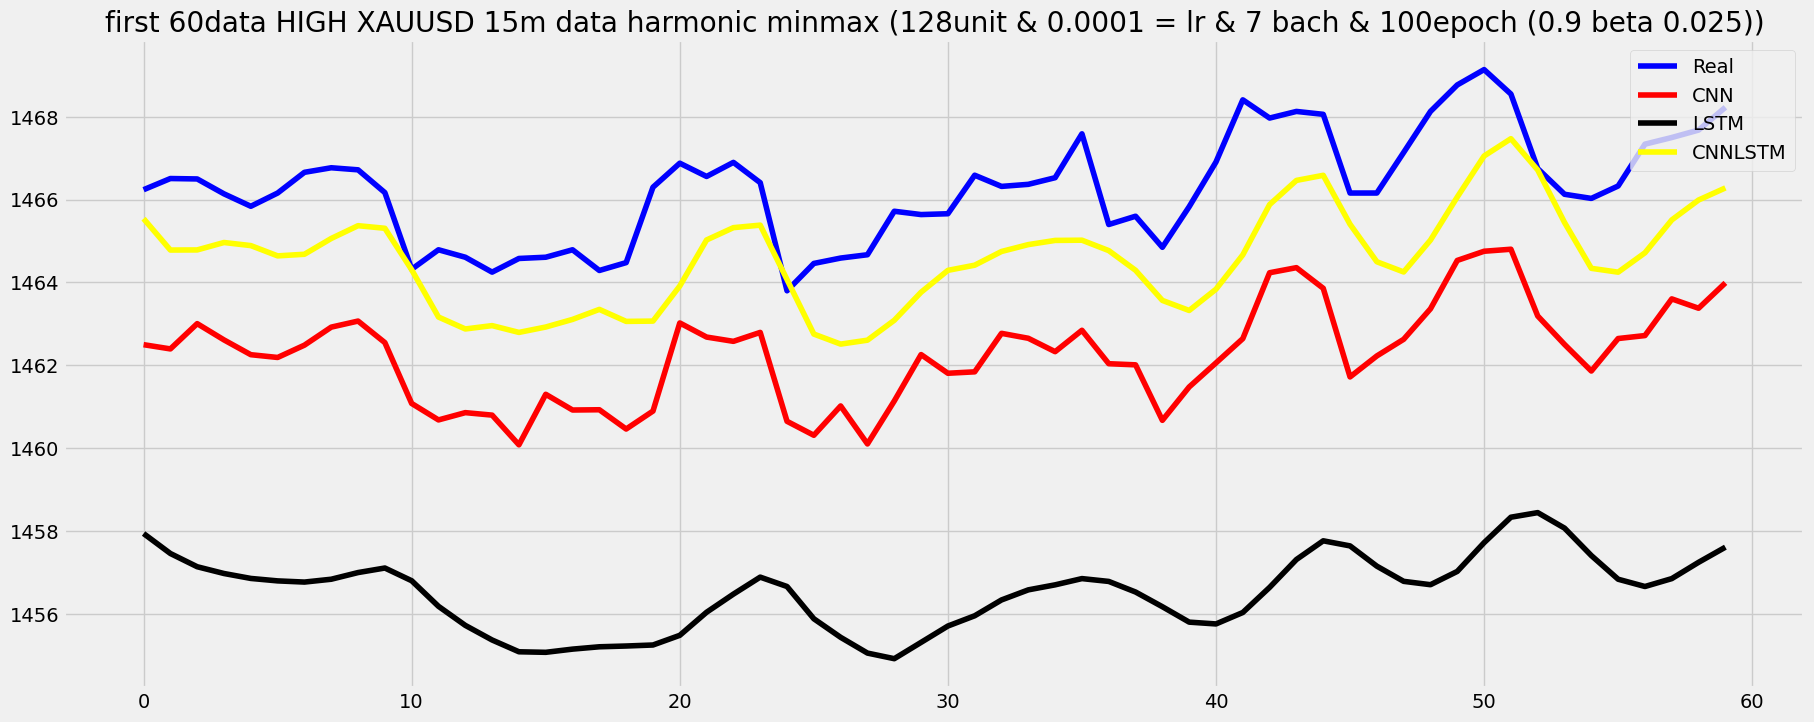

In [53]:
from matplotlib import pyplot
pyplot.figure(figsize=(20,8))

lenn = len(TestCNNLSTM_h_maxxmin15m) - 60

pyplot.plot(TestCNNLSTM_h_maxxmin15m[0:60,1], 'blue')
pyplot.plot(predsCNN_h_maxxmin15m[0:60:,1], 'red')
pyplot.plot(predsLSTM_h_maxxmin15m[0:60:,1], 'black')
pyplot.plot(predsCNNLSTM_h_maxxmin15m[0:60:,1], 'yellow')


plt.legend(('Real', 'CNN', 'LSTM','CNNLSTM'), loc='upper right')

tit = "first 60data HIGH XAUUSD 15m data harmonic minmax (128unit & 0.0001 = lr & 7 bach & 100epoch (0.9 beta 0.025))"
pyplot.title(tit)#, loc='left')

plt.savefig(r'C:\Users\Hamkaran\Desktop\Final_Project\extracted\outputs'+ tit +'.png')

pyplot.show()

## Save loss

### 15min loss

In [54]:
loss_history = histCNN_h_maxxmin15m.history["loss"]
numpy_loss_history1 = np.array(loss_history)
np.savetxt(r"C:\Users\Hamkaran\Desktop\Final_Project\extracted\loss/histCNN_h_maxxmin15m.txt" , numpy_loss_history1, delimiter=",")

loss_history = histLSTM_h_maxxmin15m.history["loss"]
numpy_loss_history2 = np.array(loss_history)
np.savetxt(r"C:\Users\Hamkaran\Desktop\Final_Project\extracted\loss/histLSTM_h_maxxmin15m.txt" , numpy_loss_history2, delimiter=",")


loss_history = histCNNLSTM_h_maxxmin15m.history["loss"]
numpy_loss_history3 = np.array(loss_history)
np.savetxt(r"C:\Users\Hamkaran\Desktop\Final_Project\extracted\loss/histCNNLSTM_h_maxxmin15m.txt" , numpy_loss_history3, delimiter=",")

print("--------------Finished----------------")

--------------Finished----------------


## Save validation loss

### val loss 15m

In [55]:
val_loss_history = histCNN_h_maxxmin15m.history["val_loss"]
numpy_loss_history1 = np.array(val_loss_history)
np.savetxt(r"C:\Users\Hamkaran\Desktop\Final_Project\extracted\loss/val_losshistCNN_h_maxxmin15m.txt" , numpy_loss_history1, delimiter=",")

val_loss_history = histLSTM_h_maxxmin15m.history["val_loss"]
numpy_loss_history2 = np.array(val_loss_history)
np.savetxt(r"C:\Users\Hamkaran\Desktop\Final_Project\extracted\loss/val_losshistLSTM_h_maxxmin15m.txt" , numpy_loss_history2, delimiter=",")

val_loss_history = histCNNLSTM_h_maxxmin15m.history["val_loss"]
numpy_loss_history3 = np.array(val_loss_history)
np.savetxt(r"C:\Users\Hamkaran\Desktop\Final_Project\extracted\loss/val_losshistCNNLSTM_h_maxxmin15m.txt" , numpy_loss_history3, delimiter=",")

print("--------------Finished----------------")

--------------Finished----------------
